In [ ]:
#주로 사용하는 library import
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

#실행9_1_1

In [ ]:
#data
data_1way = pd.DataFrame({
 'score': [100, 96 ,98, 96, 92, #A
 76, 80, 84, 84, 78, #B
 108, 100, 101, 98, 96], #C
 'group': ['A'] * 5 + ['B'] * 5 + ['C'] * 5
})
print(data_1way)

    score group
0     100     A
1      96     A
2      98     A
3      96     A
4      92     A
5      76     B
6      80     B
7      84     B
8      84     B
9      78     B
10    108     C
11    100     C
12    101     C
13     98     C
14     96     C


In [ ]:
#일원배치 분산분석
#가설) H0: 모든 그룹의 평균이 같다 / H1: 적어도 하나의 그룹 평균은 다르다(not H0)
import statsmodels.api as sm
import statsmodels.formula.api as smf

#선형모형 적합: 종속변수 ~ 집단
model_1way = smf.ols('score ~ C(group)',data_1way).fit()  #C(group): group 변수 더미처리

#분산분석표
anova_table = sm.stats.anova_lm(model_1way, typ=1 ) #typ= 1,2,3 가능
print(anova_table)

#해석
if float(anova_table.loc['C(group)', 'PR(>F)']) < 0.05:
 print("\n귀무가설을 기각합니다. 적어도 한 그룹의 평균은 다릅니다.")
else:
 print("\n귀무가설을 채택합니다. 모든 그룹의 평균이 같습니다.")

            df       sum_sq     mean_sq          F    PR(>F)
C(group)   2.0  1136.133333  568.066667  40.193396  0.000005
Residual  12.0   169.600000   14.133333        NaN       NaN

귀무가설을 기각합니다. 적어도 한 그룹의 평균은 다릅니다.


#실행9_1_2

그룹별 평균
group
A     96.4
B     80.4
C    100.6
Name: score, dtype: float64


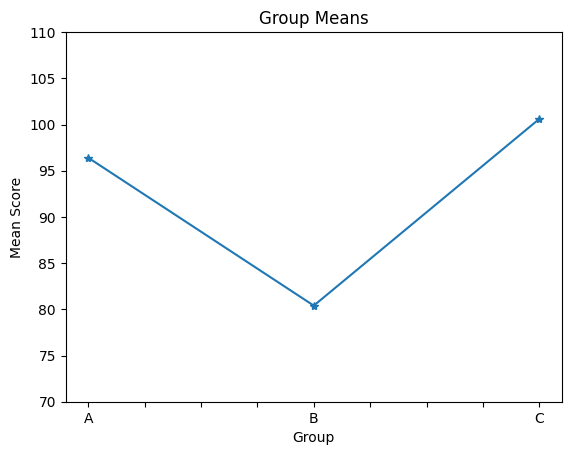

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B    -16.0 0.0001 -22.3433 -9.6567   True
     A      C      4.2  0.222  -2.1433 10.5433  False
     B      C     20.2    0.0  13.8567 26.5433   True
-----------------------------------------------------


In [ ]:
#그룹 평균 계산
means = data_1way.groupby('group')['score'].mean()
print('그룹별 평균')
print(means)

# 평균 그래프 그리기
means.plot(kind='line', x='group', y='score', marker='*', ylim=(70, 110))
plt.title('Group Means')
plt.xlabel('Group')
plt.ylabel('Mean Score')
plt.show()

#Tukey의 사후검정
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=data_1way['score'], # 종속변수
 groups=data_1way['group'], # 집단변수
 alpha=0.05)
print(tukey)
#AC는 차이가 별로 안남 (AC 한묶음 ,B 한묶음)

#실행9_2_1

In [ ]:
data_2way = pd.DataFrame({
 'y': [90.4, 90.7, 90.2, 90.2, 90.1, 90.4, 92.2, 91.6, 90.5, 93.7, 91.8, 92.8],
 'pressure': ['low'] * 6 + ['high'] * 6 ,
 'temp': [200, 220, 240, 200, 220, 240, 200, 220, 240, 200, 220, 240]
})
print(data_2way)

#연속형 그룹변수는 범주형으로 변환
data_2way['pressure'] = data_2way['pressure'].astype('category')

       y pressure  temp
0   90.4      low   200
1   90.7      low   220
2   90.2      low   240
3   90.2      low   200
4   90.1      low   220
5   90.4      low   240
6   92.2     high   200
7   91.6     high   220
8   90.5     high   240
9   93.7     high   200
10  91.8     high   220
11  92.8     high   240


In [ ]:
#이원배치 ANOVA: temp, pressure, 상호작용
#가설1) H0: 요인1 모든 그룹의 평균이 같다 / H1: 적어도 하나의 평균은 다르다(not H0)
#가설2) H0: 요인2 모든 그룹의 평균이 같다 / H1: 적어도 하나의 평균은 다르다(not H0)
#가설3) H0: 교호작용(=상호작용) 효과가 없다 / H1: 교호작용 효과가 있다(not H0)
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_2way = smf.ols('y ~ C(temp) * C(pressure)', data_2way).fit()
anova_table = sm.stats.anova_lm(model_2way, typ=1)
print(anova_table)

#해석
if float(anova_table.loc['C(temp):C(pressure)', 'PR(>F)']) < 0.05:
 print(f"\n(1) Interaction effect P-value ={float(anova_table.loc['C(temp):C(pressure)', 'PR(>F)']):.4f}(으)로 귀무가설을 기각합니다. 상호작용 효과가 있습니다.")
else:
 print(f"\n(1) Interaction effect P-value = {float(anova_table.loc['C(temp):C(pressure)', 'PR(>F)']):.4f}(으)로 귀무가설을 채택합니다. 상호작용 효과가 없습니다.")

if float(anova_table.loc['C(temp)', 'PR(>F)']) < 0.05:
 print(f"\n(2) Temp effect P-value = {float(anova_table.loc['C(temp)',
'PR(>F)']):.4f}(으)로 귀무가설을 기각합니다. 수준간 평균차이가 있습니다.")
else:
 print(f"\n(2) Temp effect P-value = {float(anova_table.loc['C(temp)',
'PR(>F)']):.4f}(으)로 귀무가설을 채택합니다. 수준간 평균이 같습니다.")

if float(anova_table.loc['C(pressure)', 'PR(>F)']) < 0.05:
 print(f"\n(3) Pressure effect P-value = {float(anova_table.loc['C(pressure)',
'PR(>F)']):.4f}(으)로 귀무가설을 기각합니다. 수준간 평균차이가 있습니다.")
else:
 print(f"\n(3) Pressure effect P-value = {float(anova_table.loc['C(pressure)',
'PR(>F)']):.4f}(으)로 귀무가설을 채택합니다. 수준간 평균이 같습니다.")


                      df    sum_sq   mean_sq          F    PR(>F)
C(temp)              2.0  1.011667  0.505833   0.756858  0.509201
C(pressure)          1.0  9.363333  9.363333  14.009975  0.009589
C(temp):C(pressure)  2.0  1.171667  0.585833   0.876559  0.463473
Residual             6.0  4.010000  0.668333        NaN       NaN

(1) Interaction effect P-value = 0.4635(으)로 귀무가설을 채택합니다. 상호작용 효과가 없습니다.

(2) Temp effect P-value = 0.5092(으)로 귀무가설을 채택합니다. 수준간 평균이 같습니다.

(3) Pressure effect P-value = 0.0096(으)로 귀무가설을 기각합니다. 수준간 평균차이가 있습니다.


In [ ]:
#이원배치 ANOVA: temp, pressure / 상호작용 없이
model_2way = smf.ols('y ~ C(temp) + C(pressure)', data=data_2way).fit()
anova_table = sm.stats.anova_lm(model_2way, typ=1)
print(anova_table)

              df    sum_sq   mean_sq          F    PR(>F)
C(temp)      2.0  1.011667  0.505833   0.780959  0.489982
C(pressure)  1.0  9.363333  9.363333  14.456095  0.005221
Residual     8.0  5.181667  0.647708        NaN       NaN


#실행9_2_2.이원배치 분산분석의 사후분석


그룹별 평균
temp        200   220    240
pressure                    
high      92.95  91.7  91.65
low       90.30  90.4  90.30
그룹별 평균
pressure  temp
high      200     92.95
          220     91.70
          240     91.65
low       200     90.30
          220     90.40
          240     90.30
Name: y, dtype: float64


/tmp/ipython-input-16634339.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means1 = data_2way.groupby(['pressure', 'temp'])['y'].mean().unstack()
/tmp/ipython-input-16634339.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means2 = data_2way.groupby(['pressure', 'temp'])['y'].mean()


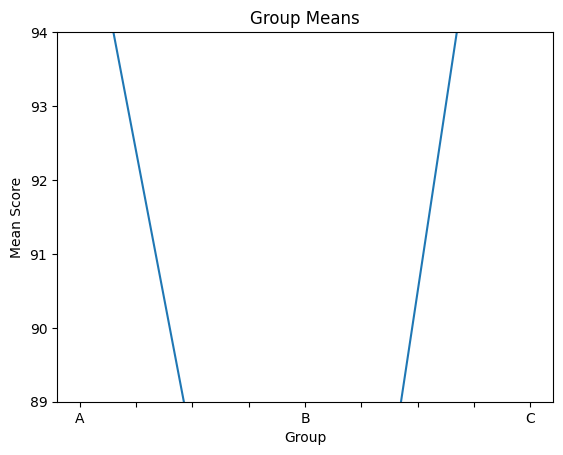

In [ ]:
#실행9_2_2
#그룹 평균 계산
means1 = data_2way.groupby(['pressure', 'temp'])['y'].mean().unstack()
print('그룹별 평균')
print(means1)

means2 = data_2way.groupby(['pressure', 'temp'])['y'].mean()
print('그룹별 평균')
print(means2)

#평균 그래프 그리기
means.plot(kind='line', marker='*', ylim=(89, 94))
plt.title('Group Means')
plt.xlabel('Group')
plt.ylabel('Mean Score')
plt.show()

In [ ]:
#Tukey의 사후검정
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey1 = pairwise_tukeyhsd(endog=data_2way['y'], groups=data_2way['pressure'], alpha=0.05)
print()
print(tukey1)

#Tukey의 사후검정
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey2 = pairwise_tukeyhsd(endog=data_2way['y'], groups=data_2way['temp'], alpha=0.05)
print()
print(tukey2)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower   upper  reject
--------------------------------------------------
  high    low  -1.7667 0.003 -2.779 -0.7543   True
--------------------------------------------------

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   200    220   -0.575 0.8026 -3.0848 1.9348  False
   200    240    -0.65 0.7565 -3.1598 1.8598  False
   220    240   -0.075 0.9962 -2.5848 2.4348  False
---------------------------------------------------


#연습9_1

In [ ]:
import statsmodels.api as sm
df_tooth = sm.datasets.get_rdataset('ToothGrowth').data

In [ ]:
import statsmodels. formula. api as smf
df_tooth['dose'] = df_tooth['dose'].astype('category')
tg_model = smf.ols('len~C(dose)', df_tooth).fit()
anova_table1=sm.stats.anova_lm(tg_model, typ=1)
if float(anova_table1.loc['C(dose)','PR(>F)']) <0.05:
  print('귀무가설을 기각한다. 약 복용량에 따라 치아 길이 평균이 달라진다')
else:
  print('귀무가설을 채택한다. 약 복용량에 따라 치아 길이 평균이 다르지 않다')
from statsmodels. stats. multicomp import pairwise_tukeyhsd
tukey1= pairwise_tukeyhsd(endog=df_tooth['len'], groups=df_tooth['dose'], alpha=0.5)
print(tukey1)

귀무가설을 기각한다. 약 복용량에 따라 치아 길이 평균이 달라진다
Multiple Comparison of Means - Tukey HSD, FWER=0.50
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   0.5    1.0     9.13   0.0  7.6146 10.6454   True
   0.5    2.0   15.495   0.0 13.9796 17.0104   True
   1.0    2.0    6.365   0.0  4.8496  7.8804   True
---------------------------------------------------


In [ ]:
model2=smf.ols('len~C(dose)*C(supp)', df_tooth).fit()
anova_table2=sm.stats.anova_lm(model2, typ=1)
if float(anova_table2.loc['C(dose):C(supp)','PR(>F)']) <0.05:
  print('귀무가설을 기각한다. 약 복용량에 상호작용 효과가 있다')
else:
  print('귀무가설을 채택한다. 약 복용량에 상호작용 효과가 없다')

귀무가설을 기각한다. 약 복용량에 상호작용 효과가 있다
